# Advanced Example: The Three-Body Problem

This notebook demonstrates the NHODE framework on the 3D three-body gravitational problem.

**The system:**  
Three point masses $m_0, m_1, m_2$ interact via mutual gravitational attraction in 3D. We have added a softening parameter $\varepsilon$ for numerical stability:

$$U(q) = -G \sum_{i < j} \frac{m_i m_j}{\sqrt{\|r_i - r_j\|^2 + \varepsilon^2}}$$

**The goal:**  
$m_0$ and $m_2$ are fully observed during training, while $m_1$ is hidden. Models must implicitly infer $m_1$ to accurately predict the full system dynamics.

**Models compared:**

| Model | Abbreviation | Input | Structure |
|-------|-------------|-------|-----------|
| NHODE potential energy | NHODE $_\text{pot}$ | $q \in \mathbb{R}^9$ | Learns $U_\theta(q)$ from pairwise distances, derives $\dot{x}$ via Hamilton's eqs. Known masses. |
| NHODE total energy | NHODE $_\text{tot}$ | $x \in \mathbb{R}^{18}$ | Learns $\mathcal{H}_\theta(x)$, mass-agnostic, energy-conserving. |
| Physically-structured NODE | NODE $_\text{phys}$ | $x \in \mathbb{R}^{18}$ | Known masses for $\dot{q} = p/m$; MLP predicts $\dot{p}$. |
| Vanilla NODE | NODE $_\text{vanilla}$ | $x \in \mathbb{R}^{18}$ | MLP predicts full $\dot{x}$ — no physics structure. |

**State:** canonical coordinates $x = [q_{x0}, q_{y0}, q_{z0},\; q_{x1}, q_{y1}, q_{z1},\; q_{x2}, q_{y2}, q_{z2},\; p_{x0}, p_{y0}, p_{z0},\; p_{x1}, p_{y1}, p_{z1},\; p_{x2}, p_{y2}, p_{z2}]$ (18-dimensional).  
**Observed:** all of $m_0$ (indices 0–2, 9–11) and $m_2$ (indices 6–8, 15–17).  
**Latent:** all of $m_1$ (indices 3–5, 12–14).


In [1]:
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax as dfx
import optax
import matplotlib.pyplot as plt
from typing import Dict, List, Optional, Tuple
from pathlib import Path
import matplotlib.patches as mpatches

jax.config.update("jax_enable_x64", False)
print("JAX devices:", jax.devices())


JAX devices: [CpuDevice(id=0)]


In [2]:
# Font settings
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'sans-serif'

# Color palette
COLORS = {
    "nhode_pot":    "#2160B3",   # Blue
    "nhode_tot":    "#74c6ec",   # Cyan
    "node_phys":    "#f0c37c",   # Yellow
    "node_vanilla": "#D27146",   # Orange
    "true":         "#777777",   # Grey
}

LABELS = {
    "nhode_pot":    f"NHODE$_\mathrm{{pot}}$",
    "nhode_tot":    f"NHODE$_\mathrm{{tot}}$",
    "node_phys":    f"NODE$_\mathrm{{phys}}$",
    "node_vanilla": f"NODE$_\mathrm{{vanilla}}$",
    "true":         "Ground truth",
}


## 1. Define the physical system

The three-body problem has 4 parameters: masses $m_0, m_1, m_2$ and gravitational constant $G$. In addition, we use relatively large values of the Plummer softening parameter $\varepsilon$ for numerical stability.

The **Hamiltonian** (total mechanical energy) is:

$$\mathcal{H}(q, p) = \underbrace{\sum_{i=0}^{2} \frac{\|p_i\|^2}{2m_i}}_{\text{Kinetic energy}} - \underbrace{G \sum_{i < j} \frac{m_i m_j}{\sqrt{\|r_i - r_j\|^2 + \varepsilon^2}}}_{\text{Potential energy}}$$

Hamilton's equations give the equations of motion:

$$\dot{q}_i = \frac{\partial \mathcal{H}}{\partial p_i}, \qquad \dot{p}_i = -\frac{\partial \mathcal{H}}{\partial q_i} $$

We integrate these via `jax.grad` to generate training data.


In [3]:
class Params(eqx.Module):
    m0: float; m1: float; m2: float   # masses
    G: float                           # gravitational constant

# System parameters (matching experiment)
params = Params(m0=1.0, m1=1.0, m2=1.0, G=1.0)

# Plummer softening  (ε = 0.6 matching experiment configs)
EPSILON = 0.6


def true_hamiltonian(x, params):
    """True Hamiltonian H(q, p) = kinetic + Plummer gravitational potential.
    x = [qx0,qy0,qz0, qx1,qy1,qz1, qx2,qy2,qz2, px0,py0,pz0, px1,py1,pz1, px2,py2,pz2]  (18,)
    """
    r0, r1, r2 = x[0:3], x[3:6], x[6:9]
    p0, p1, p2 = x[9:12], x[12:15], x[15:18]

    T = (jnp.dot(p0, p0) / (2.0 * params.m0) +
         jnp.dot(p1, p1) / (2.0 * params.m1) +
         jnp.dot(p2, p2) / (2.0 * params.m2))

    V01 = -params.G * params.m0 * params.m1 / jnp.sqrt(jnp.sum((r0 - r1)**2) + EPSILON**2)
    V02 = -params.G * params.m0 * params.m2 / jnp.sqrt(jnp.sum((r0 - r2)**2) + EPSILON**2)
    V12 = -params.G * params.m1 * params.m2 / jnp.sqrt(jnp.sum((r1 - r2)**2) + EPSILON**2)

    return T + V01 + V02 + V12


def true_vector_field(t, x, args):
    """True dynamics via Hamilton's equations: ẋ = [∂H/∂p, -∂H/∂q].
    x = [qx0,qy0,qz0, qx1,qy1,qz1, qx2,qy2,qz2, px0,py0,pz0, px1,py1,pz1, px2,py2,pz2]  (18,)
    """
    _, params = args
    dHdx = jax.grad(true_hamiltonian)(x, params)
    dqdt =  dHdx[9:]   # ∂H/∂p  →  q̇
    dpdt = -dHdx[:9]   # −∂H/∂q →  ṗ
    return jnp.concatenate([dqdt, dpdt])


## 2. Generate training data

Initial conditions are sampled from uniform distributions with fixed spatial regions, with random velocities converted to momenta $p_i = m_i v_i$. Zero total momentum is enforced.


In [4]:
key = jax.random.PRNGKey(0)


# ── IC sampling ────────────────────────────────────────────────────────────────
def sample_ic_batch(key, N, params):
    """Sample initial conditions in canonical form [positions, momenta].
    Positions drawn from fixed non-overlapping regions; p = m*v with zero total momentum.
    Returns shape (N, 18): x = [qx0,qy0,qz0, qx1,qy1,qz1, qx2,qy2,qz2, px0,py0,pz0, px1,py1,pz1, px2,py2,pz2]
    """
    keys = jax.random.split(key, 10)
    masses = jnp.array([params.m0, params.m1, params.m2])

    # Positions — each mass in its own spatial region (matching experiment)
    qx0 = jax.random.uniform(keys[0], (N,), minval=0.3, maxval=0.7)
    qy0 = jax.random.uniform(keys[1], (N,), minval=1.0, maxval=1.4)
    qz0 = jax.random.uniform(keys[2], (N,), minval=-0.1, maxval=0.1)

    qx1 = jax.random.uniform(keys[3], (N,), minval=0.1, maxval=0.4)
    qy1 = jax.random.uniform(keys[4], (N,), minval=0.1, maxval=0.5)
    qz1 = jax.random.uniform(keys[5], (N,), minval=-0.1, maxval=0.1)

    qx2 = jax.random.uniform(keys[6], (N,), minval=0.6, maxval=0.9)
    qy2 = jax.random.uniform(keys[7], (N,), minval=0.1, maxval=0.5)
    qz2 = jax.random.uniform(keys[8], (N,), minval=-0.1, maxval=0.1)

    q = jnp.stack([qx0, qy0, qz0, qx1, qy1, qz1, qx2, qy2, qz2], axis=-1)  # (N, 9)

    # Velocities — uniform random with zero total momentum enforced → p = m*v
    v = jax.random.uniform(keys[9], (N, 3, 3), minval=-0.3, maxval=0.3)   # (N, nbodies, ndim)
    M = jnp.sum(masses)
    V_cm = jnp.einsum('b,nbd->nd', masses, v) / M   # (N, 3)
    v -= V_cm[:, None, :]                             # zero total momentum
    p = (v * masses[None, :, None]).reshape(N, 9)    # p = m*v,  (N, 9)

    return jnp.concatenate([q, p], axis=-1)   # (N, 18)


# ── Integration helper ──────────────────────────────────────────────────────────
def integrate(term_fn, ts, params, y0s):
    """Integrate a vector field for a batch of initial conditions.
    x is canonical: [positions (9), momenta (9)]
    """
    ts = jnp.asarray(ts)
    t0, t1 = float(ts[0]), float(ts[-1])
    term = dfx.ODETerm(term_fn)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts)
    controller = dfx.PIDController(rtol=1e-5, atol=1e-6)

    def solve_one(y0):
        sol = dfx.diffeqsolve(term, solver, t0=t0, t1=t1, dt0=None,
                              y0=y0, args=(None, params),
                              saveat=saveat, stepsize_controller=controller,
                              max_steps=16384)
        return sol.ys
    return jax.vmap(solve_one)(y0s)


# ── Generate dataset (matching experiment: N=2000, T=3.0, steps=1001) ──────────
N_traj = 2000
ts = jnp.linspace(0.0, 3.0, 1001)

key, subkey = jax.random.split(key)
ics = sample_ic_batch(subkey, N_traj, params)          # (N, 18)
xs  = integrate(true_vector_field, ts, params, ics)    # (N, T, 18)

print(f"Dataset shape: {xs.shape}  →  (trajectories, time steps, state dim)")


Dataset shape: (2000, 1001, 18)  →  (trajectories, time steps, state dim)


Train: 1700 trajectories  |  Val: 300 trajectories


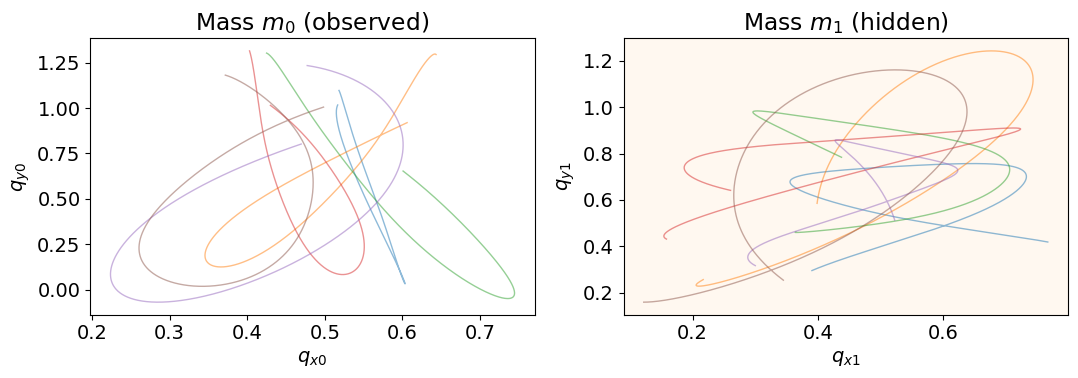

In [5]:
# ── Train / validation split ────────────────────────────────────────────────
key, subkey = jax.random.split(key)
idx = jax.random.permutation(subkey, N_traj)
n_train = int(0.85 * N_traj)
train_data = xs[idx[:n_train]]    # (N_train, T, 18)
val_data   = xs[idx[n_train:]]    # (N_val,   T, 18)
print(f"Train: {train_data.shape[0]} trajectories  |  Val: {val_data.shape[0]} trajectories")

# ── Visualise a few training trajectories (XY projection) ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for i in range(6):
    axes[0].plot(train_data[i, :, 0], train_data[i, :, 1], alpha=0.5, lw=1)  # qx0, qy0
    axes[1].plot(train_data[i, :, 3], train_data[i, :, 4], alpha=0.5, lw=1)  # qx1, qy1 (latent)
axes[0].set(xlabel="$q_{x0}$", ylabel="$q_{y0}$", title=f"Mass $m_0$ (observed)")
axes[1].set(xlabel="$q_{x1}$", ylabel="$q_{y1}$", title=f"Mass $m_1$ (hidden)")
axes[1].set_facecolor("#fff8f0")
plt.tight_layout()
plt.show()


## 3. Define the learned models

All models operate on the 18D canonical state. The NHODE models use relative-distance preprocessing — the position part of the input is replaced by the three pairwise distances $d_{01}, d_{12}, d_{02}$ (rotation- and translation-invariant). The NODE models operate directly on the 18D state, because this gave better results in practice. 

### NHODE — potential energy

Learns $U_\theta(d(\mathbf{q}))$ from 3 pairwise distances. Assume separable hamiltonian, known form of the kinetic energy and therefore also known masses. The model conserves both the total energy, linear and angular momentum by construction:

$$\dot{q}_i = \frac{p_i}{m_i}, \qquad \dot{p}_i = -\nabla_q U_\theta(d(q))$$

where $d(\mathbf{q}) = (\| \mathbf{q}_j - \mathbf{q}_k \|)_{j<k}$.

### NHODE — total energy 

Learns $\mathcal{H}_\theta(x)$ from 3 pairwise distances + 9 momenta. Conserves the total energy and linear momentum by construction.

### Physically-structured NODE

Uses known masses for $\dot{q} = p/m$, and learns $\dot{p}$ via a neural network. Not energy-conserving.

### Vanilla NODE 

A MLP directly predicts $\dot{x}$. No physics structure.


In [6]:
# ── Relative-distance preprocessing ──────────────────────────────────────────
# Replaces raw positions with the 3 pairwise distances (d01, d12, d02),
# making the models rotation- and translation-invariant.

def _pairwise_distances(q):
    """q: flat position array of shape (9,) → (3,) pairwise distances."""
    r0, r1, r2 = q[0:3], q[3:6], q[6:9]
    d01 = jnp.sqrt(jnp.sum((r0 - r1)**2) + 1e-12)
    d12 = jnp.sqrt(jnp.sum((r1 - r2)**2) + 1e-12)
    d02 = jnp.sqrt(jnp.sum((r0 - r2)**2) + 1e-12)
    return jnp.stack([d01, d12, d02])   # (3,)


# ── Model architectures ────────────────────────────────────────────────────────

class HamiltonianNN(eqx.Module):
    """Scalar energy network with pairwise-distance preprocessing.
    input_dim=9  → NHODEpot: net input is 3 distances.
    input_dim=18 → NHODEtot: net input is 3 distances + 9 momenta.
    """
    net: eqx.nn.MLP
    input_dim: int

    def __init__(self, key, input_dim, hidden_dim=128, depth=4):
        self.input_dim = input_dim
        in_size = 3 if input_dim == 9 else 12   # distances only, or distances + momenta
        self.net = eqx.nn.MLP(in_size=in_size, out_size=1,
                               width_size=hidden_dim, depth=depth,
                               activation=jax.nn.tanh, key=key)

    def _preprocess(self, x):
        q = x[:9] if self.input_dim == 18 else x
        d = _pairwise_distances(q)
        if self.input_dim == 18:
            return jnp.concatenate([d, x[9:]])     # (12,)
        return d                                   # (3,)

    def __call__(self, x):
        return self.net(self._preprocess(x))[0]   # scalar


class NeuralODE(eqx.Module):
    """MLP operating directly on the 18D state (no preprocessing).
    out_size=9  for NODE_phys (predicts dp/dt);
    out_size=18 for NODE_vanilla (predicts full dx/dt).
    """
    net: eqx.nn.MLP
    out_size: int

    def __init__(self, key, out_size, hidden_dim=128, depth=4):
        self.out_size = out_size
        self.net = eqx.nn.MLP(in_size=18, out_size=out_size,
                               width_size=hidden_dim, depth=depth,
                               activation=jax.nn.tanh, key=key)

    def __call__(self, x):
        return self.net(x)


# ── Vector fields (ODE right-hand sides) ──────────────────────────────────────

def vf_nhode_pot(t, x, args):
    """NHODEpot: dq/dt = p/m (known masses),  dp/dt = -∇_q U_θ(q)."""
    model, params = args
    masses = jnp.array([params.m0]*3 + [params.m1]*3 + [params.m2]*3)
    q, p = x[:9], x[9:]
    dqdt = p / masses
    dpdt = -jax.grad(model)(q)
    return jnp.concatenate([dqdt, dpdt])


def vf_nhode_tot(t, x, args):
    """NHODEtot: dx/dt derived from gradient of learned H_θ(x)."""
    model, _ = args
    dHdx = jax.grad(model)(x)   # (18,)
    dqdt =  dHdx[9:]            # ∂H/∂p  →  q̇
    dpdt = -dHdx[:9]            # −∂H/∂q →  ṗ
    return jnp.concatenate([dqdt, dpdt])


def vf_node_phys(t, x, args):
    """NODE_phys: dq/dt = p/m (known masses),  dp/dt = MLP(x)."""
    model, params = args
    masses = jnp.array([params.m0]*3 + [params.m1]*3 + [params.m2]*3)
    q, p = x[:9], x[9:]
    dqdt = p / masses
    dpdt = model(x)   # (9,)
    return jnp.concatenate([dqdt, dpdt])


def vf_node_vanilla(t, x, args):
    """NODE_vanilla: dx/dt = MLP(x)."""
    model, _ = args
    return model(x)   # (18,)


# ── Instantiate models (hidden_dim=128, depth=3 matching experiment) ───────────
key, k1, k2, k3, k4 = jax.random.split(key, 5)
nhode_pot_model = HamiltonianNN(k1, input_dim=9,  hidden_dim=128, depth=3)
nhode_tot_model = HamiltonianNN(k2, input_dim=18, hidden_dim=128, depth=3)
node_phys_model = NeuralODE(k3, out_size=9,  hidden_dim=128, depth=3)
node_van_model  = NeuralODE(k4, out_size=18, hidden_dim=128, depth=3)

for name, model in [("NHODE_pot",     nhode_pot_model),
                    ("NHODE_tot",     nhode_tot_model),
                    ("NODE_phys",     node_phys_model),
                    ("NODE_vanilla",  node_van_model)]:
    n = sum(leaf.size for leaf in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array)))
    print(f"{name:15s}: {n:6d} parameters")


NHODE_pot      :  33665 parameters
NHODE_tot      :  34817 parameters
NODE_phys      :  36617 parameters
NODE_vanilla   :  37778 parameters


## 4. Train

All four models share the same training loop:
1. Integrate the learned ODE forward from the initial condition $y_0$.
2. Compute MSE loss on the **observed states of $m_0$ and $m_2$** (indices 0–2, 6–8, 9–11, 15–17). $m_1$ contributes nothing to the loss.
3. Backpropagate through the ODE solver and update weights with **Adam + exponential LR decay** ($\times 0.95$ every 10 epochs, matching experiment).

The models must implicitly capture the influence of the latent mass $m_1$ to correctly predict the coupled dynamics of $m_0$ and $m_2$.


In [7]:
# State layout: x = [qx0,qy0,qz0, qx1,qy1,qz1, qx2,qy2,qz2, px0,py0,pz0, px1,py1,pz1, px2,py2,pz2]
# Observed:  m0 pos [0,1,2] + m0 mom [9,10,11] + m2 pos [6,7,8] + m2 mom [15,16,17]
# Latent:    m1 pos [3,4,5] + m1 mom [12,13,14]
OBSERVED = jnp.array([0, 1, 2, 6, 7, 8, 9, 10, 11, 15, 16, 17])


def make_integrator(vector_field, ts, params):
    """Return a vmapped batch integrator for a given vector field."""
    ts = jnp.asarray(ts)
    t0, t1 = float(ts[0]), float(ts[-1])
    term = dfx.ODETerm(vector_field)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts)
    controller = dfx.PIDController(rtol=1e-5, atol=1e-6)

    def solve_one(model, ic):
        sol = dfx.diffeqsolve(term, solver, t0=t0, t1=t1, dt0=None,
                              y0=ic, args=(model, params),
                              saveat=saveat, stepsize_controller=controller,
                              max_steps=16384)
        return sol.ys   # (T, 18)

    @eqx.filter_jit
    def run_batch(model, ics):
        return jax.vmap(lambda ic: solve_one(model, ic))(ics)

    return run_batch


def train(model, vector_field, ts, params, train_data, val_data,
          epochs=250, batch_size=64, lr=1e-3,
          lr_decay_rate=0.95, lr_decay_epochs=10,
          print_every=25, key=None):
    """Train with partial-observation MSE loss on observed states of m0 and m2.
    LR schedule and hyperparameters match experiment configs.
    """
    if key is None:
        key = jax.random.PRNGKey(42)

    run_batch = make_integrator(vector_field, ts, params)

    # ── Exponential LR schedule (matching experiment) ─────────────────────────
    steps_per_epoch = train_data.shape[0] // batch_size
    schedule = optax.exponential_decay(
        init_value=lr,
        transition_steps=lr_decay_epochs * steps_per_epoch,
        decay_rate=lr_decay_rate,
        staircase=True,
    )
    optimizer = optax.adam(learning_rate=schedule)
    print(f"LR schedule: exponential decay ×{lr_decay_rate} every {lr_decay_epochs} epochs")

    model_params, model_static = eqx.partition(model, eqx.is_array)
    opt_state = optimizer.init(model_params)

    @eqx.filter_value_and_grad
    def loss_fn(model_params, batch):
        model = eqx.combine(model_params, model_static)
        pred  = run_batch(model, batch[:, 0, :])
        return jnp.mean((pred[..., OBSERVED] - batch[..., OBSERVED]) ** 2)

    @eqx.filter_jit
    def step(model_params, opt_state, batch):
        loss, grads = loss_fn(model_params, batch)
        updates, opt_state = optimizer.update(grads, opt_state, model_params)
        model_params = eqx.apply_updates(model_params, updates)
        return model_params, opt_state, loss

    train_losses, val_losses = [], []
    N = train_data.shape[0]
    global_step = 0

    for epoch in range(1, epochs + 1):
        key, subkey = jax.random.split(key)
        perm = jax.random.permutation(subkey, N)

        epoch_losses = []
        for i in range(0, N, batch_size):
            batch = train_data[perm[i:i + batch_size]]
            if batch.shape[0] < 2:
                continue
            model_params, opt_state, loss = step(model_params, opt_state, batch)
            epoch_losses.append(float(loss))
            global_step += 1

        train_loss = float(jnp.mean(jnp.array(epoch_losses)))
        val_pred   = run_batch(eqx.combine(model_params, model_static), val_data[:batch_size, 0, :])
        val_loss   = float(jnp.mean((val_pred[..., OBSERVED] - val_data[:batch_size, ..., OBSERVED]) ** 2))
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if epoch % print_every == 0 or epoch == 1:
            current_lr = float(schedule(global_step))
            print(f"Epoch {epoch:4d}/{epochs}  train={train_loss:.6f}  val={val_loss:.6f}  lr={current_lr:.2e}")

    return eqx.combine(model_params, model_static), train_losses, val_losses


In [8]:
key, k1, k2, k3, k4 = jax.random.split(key, 5)

TRAIN_KWARGS = dict(
    ts=ts, params=params, train_data=train_data, val_data=val_data,
    epochs=100, batch_size=64, lr=1e-3,
    lr_decay_rate=0.95, lr_decay_epochs=10, print_every=25,
)

print("=" * 55)
print("Training NHODE_pot")
print("=" * 55)
nhode_pot_trained, nhode_pot_tl, nhode_pot_vl = train(
    nhode_pot_model, vf_nhode_pot, key=k1, **TRAIN_KWARGS)

print()
print("=" * 55)
print("Training NHODE_tot")
print("=" * 55)
nhode_tot_trained, nhode_tot_tl, nhode_tot_vl = train(
    nhode_tot_model, vf_nhode_tot, key=k2, **TRAIN_KWARGS)

print()
print("=" * 55)
print("Training NODE_phys")
print("=" * 55)
node_phys_trained, node_phys_tl, node_phys_vl = train(
    node_phys_model, vf_node_phys, key=k3, **TRAIN_KWARGS)

print()
print("=" * 55)
print("Training NODE_vanilla")
print("=" * 55)
node_van_trained, node_van_tl, node_van_vl = train(
    node_van_model, vf_node_vanilla, key=k4, **TRAIN_KWARGS)


Training NHODE_pot
LR schedule: exponential decay ×0.95 every 10 epochs
Epoch    1/100  train=0.049517  val=0.007348  lr=1.00e-03
Epoch   25/100  train=0.000566  val=0.000482  lr=9.03e-04
Epoch   50/100  train=0.000054  val=0.000056  lr=7.74e-04
Epoch   75/100  train=0.000014  val=0.000010  lr=6.98e-04
Epoch  100/100  train=0.000009  val=0.000007  lr=5.99e-04

Training NHODE_tot
LR schedule: exponential decay ×0.95 every 10 epochs
Epoch    1/100  train=0.120183  val=0.109606  lr=1.00e-03
Epoch   25/100  train=0.019907  val=0.019153  lr=9.03e-04
Epoch   50/100  train=0.016648  val=0.016072  lr=7.74e-04
Epoch   75/100  train=0.014036  val=0.013615  lr=6.98e-04
Epoch  100/100  train=0.012278  val=0.012460  lr=5.99e-04

Training NODE_phys
LR schedule: exponential decay ×0.95 every 10 epochs
Epoch    1/100  train=0.142432  val=0.059729  lr=1.00e-03
Epoch   25/100  train=0.006637  val=0.005894  lr=9.03e-04
Epoch   50/100  train=0.003369  val=0.002935  lr=7.74e-04
Epoch   75/100  train=0.0018

## 5. Results

### Training curves


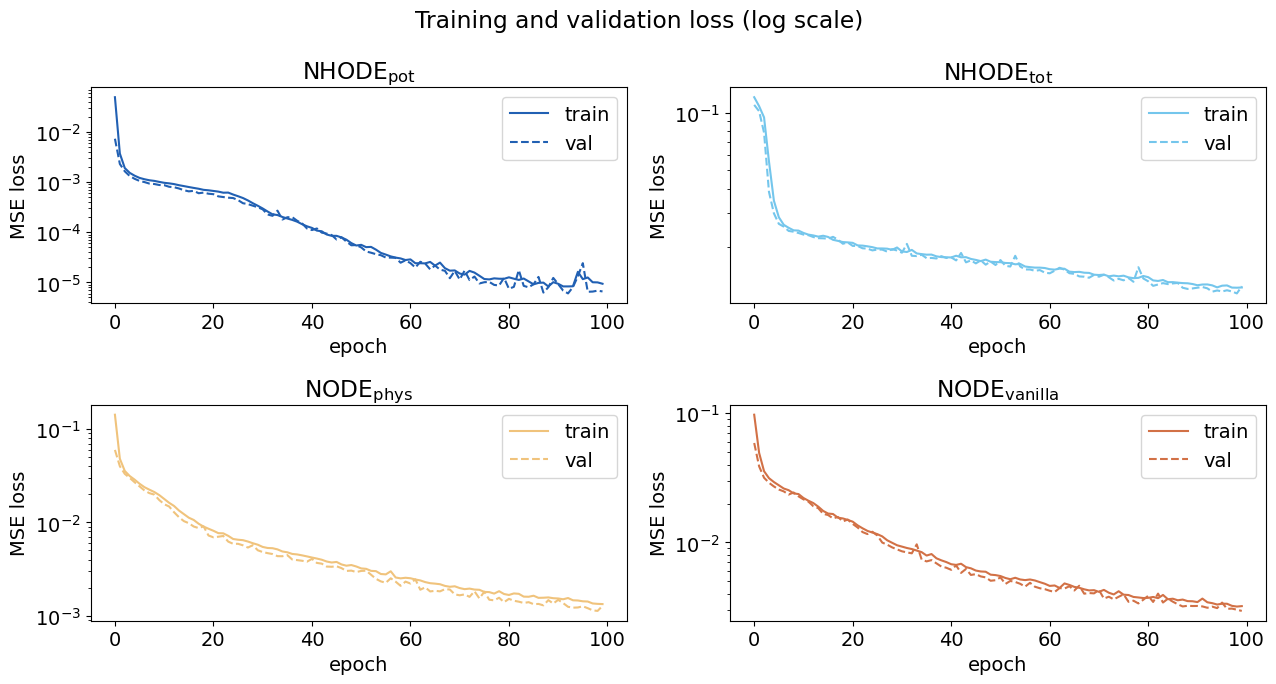

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

for ax, (mkey, tl, vl) in zip(axes.flat, [
    ("nhode_pot",    nhode_pot_tl, nhode_pot_vl),
    ("nhode_tot",    nhode_tot_tl, nhode_tot_vl),
    ("node_phys",    node_phys_tl, node_phys_vl),
    ("node_vanilla", node_van_tl,  node_van_vl),
]):
    color = COLORS[mkey]
    ax.semilogy(tl, color=color, label="train")
    ax.semilogy(vl, color=color, linestyle="--", label="val")
    ax.set(xlabel="epoch", ylabel="MSE loss", title=LABELS[mkey])
    ax.legend()

plt.suptitle("Training and validation loss (log scale)")
plt.tight_layout()
plt.show()


### Trajectory comparison on held-out test cases

We integrate all four trained models from new initial conditions on a longer time horizon and compare to ground truth.


In [49]:
# ── Generate test trajectories from new ICs ───────────────────────────────────
key, subkey = jax.random.split(key)
N_test = 10
ics_test = sample_ic_batch(subkey, N_test, params)
ts_test  = jnp.linspace(0.0, 20.0, 2001)   # extended rollout beyond training horizon

true_test = integrate(true_vector_field, ts_test, params, ics_test)   # (N_test, T, 18)

run_nhode_pot    = make_integrator(vf_nhode_pot,    ts_test, params)
run_nhode_tot    = make_integrator(vf_nhode_tot,    ts_test, params)
run_node_phys    = make_integrator(vf_node_phys,    ts_test, params)
run_node_vanilla = make_integrator(vf_node_vanilla, ts_test, params)

nhode_pot_pred = run_nhode_pot(nhode_pot_trained,    true_test[:, 0, :])
nhode_tot_pred = run_nhode_tot(nhode_tot_trained,    true_test[:, 0, :])
node_phys_pred = run_node_phys(node_phys_trained,    true_test[:, 0, :])
node_van_pred  = run_node_vanilla(node_van_trained,  true_test[:, 0, :])


In [50]:
def plot_snapshot_grid(
    true_traj: jnp.ndarray,
    predictions_dict: Dict[str, jnp.ndarray],
    snapshot_indices: List[int],
    timesteps: jnp.ndarray,
    figsize: Tuple[float, float] = (20, 16),
    save_path: Optional[Path] = None,
    fontsize: int = 14,
    xlim: Tuple[float, float] = (-0.5, 1.5),
    ylim: Tuple[float, float] = (-0.5, 2.0),
    wspace: float = 0.1,
    hspace: float = 0.1,
):
    """
    Plot a grid of 3D→XY snapshots at specified time indices.
    Rows = time snapshots; columns = ground truth + each method.
    """
    import matplotlib.patches as mpatches

    methods_ordered = list(predictions_dict.keys())[::-1]
    n_rows = len(snapshot_indices)
    n_cols = 1 + len(methods_ordered)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    plt.subplots_adjust(wspace=wspace, hspace=hspace)

    # Mass colors and labels
    mass_colors = ["#3D82C6", "#E19A61", "#8FE7FF"]
    mass_labels_snap = [r"$m_0$ (observed)", r"$m_1$ (unobserved)", r"$m_2$ (observed)"]

    def draw_snapshot(ax, traj, t_idx, trail_length=400):
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_aspect('equal')
        ax.set_facecolor("#f8f8f8")
        ax.grid(True, alpha=0.2)
        ax.set_xticks([])
        ax.set_yticks([])

        # Fading trail
        if t_idx > 0:
            trail_start = max(0, t_idx - trail_length)
            n_segments = min(t_idx - trail_start, 80)
            for mass_i in range(3):
                xi, yi = mass_i * 3, mass_i * 3 + 1   # 3D state: stride 3
                seg_idx = jnp.linspace(trail_start, t_idx, n_segments + 1, dtype=int)
                for seg in range(n_segments):
                    alpha = 0.08 + 0.65 * (seg / n_segments)
                    lw    = 0.8  + 8.0  * (seg / n_segments)
                    i0, i1 = int(seg_idx[seg]), int(seg_idx[seg + 1])
                    ax.plot(traj[i0:i1+1, xi], traj[i0:i1+1, yi],
                            color=mass_colors[mass_i], alpha=alpha,
                            linewidth=lw, solid_capstyle='round', zorder=2)

        # Current positions (XY projection)
        pos = traj[t_idx, :9].reshape(3, 3)   # (3 bodies, 3 coords)
        for mass_i in range(3):
            ax.scatter(pos[mass_i, 0], pos[mass_i, 1],
                       s=300, color=mass_colors[mass_i],
                       edgecolors='black', linewidths=1.5, zorder=3)

    # Column headers
    col_labels = ["True"] + [LABELS.get(m, m) for m in methods_ordered]
    for col_idx, label in enumerate(col_labels):
        axes[0, col_idx].set_title(label, fontsize=fontsize + 2, pad=10)

    # Row labels (time)
    for row_idx, t_idx in enumerate(snapshot_indices):
        t_val = float(timesteps[t_idx])
        axes[row_idx, 0].set_ylabel(f"t = {t_val:.1f}", fontsize=fontsize,
                                     rotation=0, labelpad=45, va='center')

    # Fill each cell
    for row_idx, t_idx in enumerate(snapshot_indices):
        draw_snapshot(axes[row_idx, 0], true_traj, t_idx)
        for col_idx, method in enumerate(methods_ordered):
            draw_snapshot(axes[row_idx, col_idx + 1], predictions_dict[method], t_idx)

    # Shared legend
    legend_elements = [
        plt.scatter([], [], s=150, color=mass_colors[i], edgecolors='black',
                    linewidths=1.5, label=mass_labels_snap[i])
        for i in range(3)
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3,
               fontsize=fontsize + 2, bbox_to_anchor=(0.5, -0.0), framealpha=0.9)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


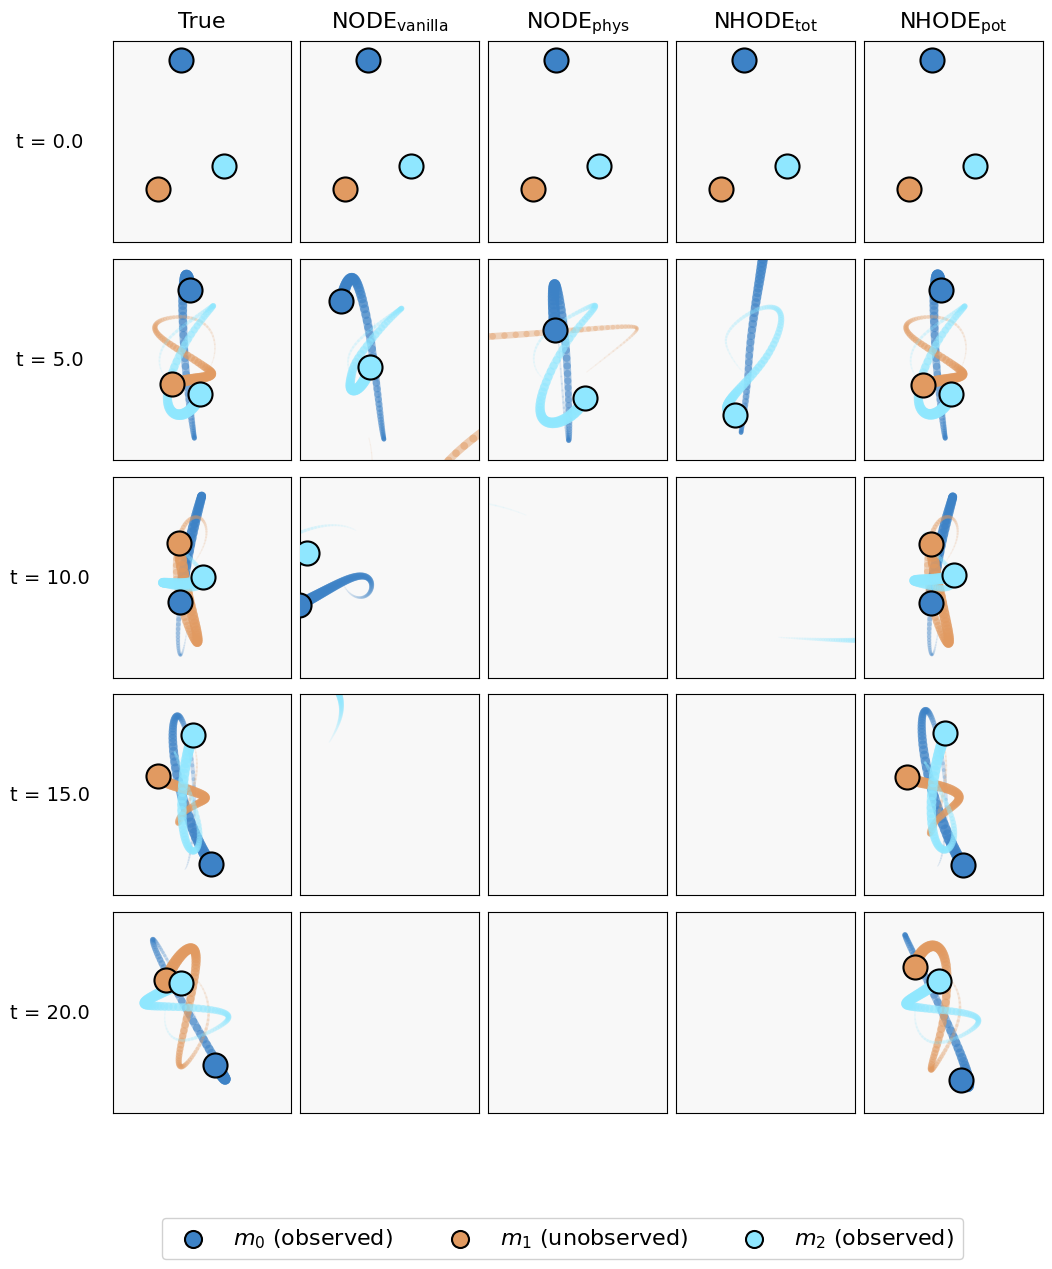

In [59]:
ic_idx = 2
snapshot_indices = [0, 500, 1000, 1500, 2000]

predictions_for_snapshot = {
    "nhode_pot":    jnp.asarray(nhode_pot_pred[ic_idx]),
    "nhode_tot":    jnp.asarray(nhode_tot_pred[ic_idx]),
    "node_phys":    jnp.asarray(node_phys_pred[ic_idx]),
    "node_vanilla": jnp.asarray(node_van_pred[ic_idx]),
}

plot_snapshot_grid(
    true_traj=jnp.asarray(true_test[ic_idx]),
    predictions_dict=predictions_for_snapshot,
    snapshot_indices=snapshot_indices,
    timesteps=jnp.asarray(ts_test),
    figsize=(12, 14),
    fontsize=14,
    xlim=(-0.3, 1.3),
    ylim=(-0.3, 1.5),
    wspace=0.05,
    hspace=0.05,
    save_path=None,
)


### Energy conservation

We evaluate the true Hamiltonian $\mathcal{H}(q, p)$ on each predicted trajectory and normalise it by the true total energy.

$$\mathcal{H}(q, p) = \sum_{i=0}^{2} \frac{\|p_i\|^2}{2m_i} - G \sum_{i < j} \frac{m_i m_j}{\sqrt{\|r_i - r_j\|^2 + \varepsilon^2}}$$

Note: NHODE $_\text{pot}$ and NHODE $_\text{tot}$ are guaranteed to conserve their learned $\mathcal{H}_\theta$; deviations in the true energy indicate a mismatch between the learned and true Hamiltonians.


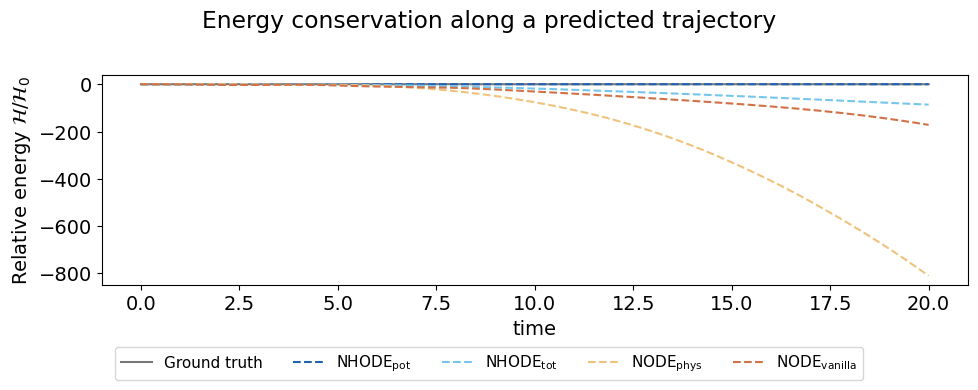

In [74]:
ic_idx = 2 # test trajectory number

figsize = (10, 3.5)

fig, ax = plt.subplots(figsize=figsize)

energy = lambda xs: jax.vmap(lambda x: true_hamiltonian(x, params))(xs)

E0 = energy(true_test[ic_idx])[0]   # reference energy at t=0
for traj, mkey in [(true_test[ic_idx],       "true"),
                   (nhode_pot_pred[ic_idx],  "nhode_pot"),
                   (nhode_tot_pred[ic_idx],  "nhode_tot"),
                   (node_phys_pred[ic_idx],  "node_phys"),
                   (node_van_pred[ic_idx],   "node_vanilla")]:
    E = energy(traj)
    ax.plot(ts_test, E / E0,
            color=COLORS[mkey], lw=1.5,
            linestyle="-" if mkey == "true" else "--",
            label=LABELS[mkey])

ax.set_xlabel("time")
ax.set_ylabel(r"Relative energy $\mathcal{H} / \mathcal{H}_0$")

handles, labels_leg = ax.get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="lower center", ncol=len(handles),
           fontsize=11, bbox_to_anchor=(0.5, -0.08), frameon=True)

plt.suptitle("Energy conservation along a predicted trajectory", y=1.0)
plt.tight_layout()
plt.show()
